In [1]:
import os, sys
sys.path.insert(0, '/home/yajatyadav/multitask_reinforcement_learning/multitask_RL')
os.chdir('/home/yajatyadav/multitask_reinforcement_learning/multitask_RL')
os.environ['CUDA_VISIBLE_DEVICES'] = '5'
from envs.libero_utils import get_single_dataset
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import tqdm
import numpy as np
from envs.libero_utils import LANGUAGE_EMBEDDERS
import re
import jax.numpy as jnp
from jax import tree_util
from envs.libero_utils import Dataset, MultiDatasetWrapper

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/yajatyadav/multitask_reinforcement_learning/multitask_RL/.venv/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [2]:
rollouts = Path('/home/yajatyadav/multitask_reinforcement_learning/multitask_RL/bcactor_collected_rollouts/bcflow_libero_90_25_demo_ckpt_80k')
# # gather all task names, with diff. gpu files being grouped in a single task name
task_names = []
for file in os.listdir(rollouts): # only iterate over directories
    if os.path.isdir(rollouts / file):
        task_names.append(file)

task_trajs = {}
for task in tqdm.tqdm(task_names, total=len(task_names)):
    task_trajs[task] = []
    # pattern match all trajs_*.pkl files
    trajs = list(Path(rollouts / task).glob('trajs_*.pkl'))
    task_trajs[task].extend(trajs)
# for gpu_id in os.listdir(rollouts):
#     for task in os.listdir(rollouts / gpu_id):
#     print(task)
#     trajs = list(Path(rollouts / task).glob('trajs_*.pkl'))[0]
#     renders = list(Path(rollouts / task).glob('renders_*.pkl'))[0]
#     eval_info = list(Path(rollouts / task).glob('eval_info_*.pkl'))[0]

#     # load all
#     trajs = pickle.load(open(trajs, 'rb'))
#     renders = pickle.load(open(renders, 'rb'))
#     eval_info = pickle.load(open(eval_info, 'rb'))

#     print(renders)

100%|██████████| 90/90 [00:00<00:00, 31684.35it/s]


In [3]:
# import os
# import pickle
# import h5py
# import numpy as np
# from pathlib import Path
# from jax import tree_util
# import tqdm

# def batch_dicts(dicts):
#     return tree_util.tree_map(lambda *xs: np.stack(xs, axis=0), *dicts)

# def save_dict_to_hdf5(group, d):
#     """Recursively save nested dict to hdf5 group."""
#     for k, v in d.items():
#         if isinstance(v, dict):
#             subgroup = group.create_group(k)
#             save_dict_to_hdf5(subgroup, v)
#         else:
#             group.create_dataset(k, data=np.array(v))

# def convert_pkl_dir_to_hdf5(input_dir):
#     input_path = Path(input_dir)
#     output_path = input_path.parent / (input_path.name + '_hdf5')
#     output_path.mkdir(parents=True, exist_ok=True)
    
#     for subdir in tqdm.tqdm(list(input_path.iterdir()), desc="Processing subdirs"):
#         if not subdir.is_dir():
#             continue
        
#         # Create corresponding output subdir
#         out_subdir = output_path / subdir.name
#         out_subdir.mkdir(parents=True, exist_ok=True)
        
#         # Gather all trajs*.pkl files
#         pkl_files = sorted(subdir.glob('trajs*.pkl'))
#         if not pkl_files:
#             print(f"No trajs*.pkl files in {subdir.name}, skipping...")
#             continue
        
#         print(f"Processing {subdir.name}: found {len(pkl_files)} pkl files")
        
#         # Accumulate across all pkl files
#         all_obs = []
#         all_next_obs = []
#         all_actions = []
#         all_rewards = []
#         all_dones = []
        
#         for pkl_file in tqdm.tqdm(pkl_files, desc=f"Loading pkls in {subdir.name}", leave=False):
#             with open(pkl_file, 'rb') as f:
#                 dataset = pickle.load(f)
            
#             for ep in dataset:
#                 all_obs.extend(ep['observations'])
#                 all_next_obs.extend(ep['next_observations'])
#                 all_actions.append(np.array(ep['actions']))
#                 all_rewards.append(np.array(ep['rewards']))
#                 all_dones.append(np.array(ep['dones']))
        
#         # Batch/concatenate everything
#         obs_batched = batch_dicts(all_obs)
#         next_obs_batched = batch_dicts(all_next_obs)
#         actions = np.concatenate(all_actions, axis=0)
#         rewards = np.concatenate(all_rewards, axis=0)
#         dones = np.concatenate(all_dones, axis=0)
        
#         print(f"  Total timesteps: {actions.shape[0]}")
        
#         # Save to single hdf5
#         hdf5_file = out_subdir / 'rollouts.hdf5'
#         with h5py.File(hdf5_file, 'w') as hf:
#             save_dict_to_hdf5(hf.create_group('observations'), obs_batched)
#             save_dict_to_hdf5(hf.create_group('next_observations'), next_obs_batched)
#             hf.create_dataset('actions', data=actions)
#             hf.create_dataset('rewards', data=rewards)
#             hf.create_dataset('dones', data=dones)
        
#         print(f"  Saved to {hdf5_file}")
    
#     print(f"Done. Output dir: {output_path}")

# # Usage
# convert_pkl_dir_to_hdf5('/home/yajatyadav/multitask_reinforcement_learning/multitask_RL/bcactor_collected_rollouts/bcflow_libero_90_25_demo_ckpt_80k')

In [4]:


# def load_hdf5_to_dict(group):
#     """Recursively load hdf5 group into nested dict."""
#     result = {}
#     for k, v in group.items():
#         if isinstance(v, h5py.Group):
#             result[k] = load_hdf5_to_dict(v)
#         else:
#             result[k] = v[:]  # Load dataset into numpy array
#     return result

# def create_dataset_from_hdf5(hdf5_path, action_clip_eps=1e-5):
#     with h5py.File(hdf5_path, 'r') as hf:
#         observations = load_hdf5_to_dict(hf['observations'])
#         next_observations = load_hdf5_to_dict(hf['next_observations'])
#         actions = hf['actions'][:]
#         rewards = hf['rewards'][:]
#         dones = hf['dones'][:]
    
#     # Clip actions
#     actions = np.clip(actions, -1 + action_clip_eps, 1 - action_clip_eps)
    
#     # Cast to float32
#     observations = tree_util.tree_map(lambda x: x.astype(np.float32), observations)
#     next_observations = tree_util.tree_map(lambda x: x.astype(np.float32), next_observations)
#     actions = actions.astype(np.float32)
#     rewards = rewards.astype(np.float32)
#     terminals = dones.astype(np.float32)
#     masks = 1.0 - terminals
    
#     print(f"Loaded {actions.shape[0]} timesteps from {hdf5_path}")
    
#     return Dataset.create(
#         observations=observations,
#         next_observations=next_observations,
#         actions=actions,
#         rewards=rewards,
#         terminals=terminals,
#         masks=masks,
#     )


In [5]:
# hdf_files_path = '/home/yajatyadav/multitask_reinforcement_learning/multitask_RL/bcactor_collected_rollouts/bcflow_libero_90_25_demo_ckpt_80k_hdf5'
# import glob
# all_datasets = []
# for subdir in tqdm.tqdm(os.listdir(hdf_files_path), total=len(os.listdir(hdf_files_path))):
#     # pattern-match to the hdf5 file
#     pattern = os.path.join(hdf_files_path, subdir, 'rollouts.hdf5')
#     file = sorted(glob.glob(pattern))[0]
#     # print(file)
#     all_datasets.append(create_dataset_from_hdf5(file))
# multi_task_dataset = MultiDatasetWrapper(all_datasets)

In [6]:
import os
import pickle
import h5py
import numpy as np
from pathlib import Path
from jax import tree_util
import tqdm

def batch_dicts(dicts):
    return tree_util.tree_map(lambda *xs: np.stack(xs, axis=0), *dicts)

def stack_dict_list(dict_list):
    """Stack a list of dictionaries into a dictionary of stacked arrays."""
    if not dict_list:
        return {}
    keys = dict_list[0].keys()
    return {k: np.concatenate([d[k] for d in dict_list], axis=0) for k in keys}

# def process_task(task_paths, task_str, action_clip_eps=1e-5):
#     # takes a list of paths to pickle files containing trajectories, and creates a Dataset object

#     # initialize everything needed
#     observations = []
#     actions = []
#     next_observations = []
#     terminals = []
#     rewards = []
#     masks = []
#     successes = []

#     num_timesteps = 0
#     for path in tqdm.tqdm(task_paths, total=len(task_paths), desc=f"Processing files for task {task_str}", position=1, leave=False):
#         dataset = pickle.load(open(path, 'rb'))
#         for i, ep in tqdm.tqdm(enumerate(dataset), total=len(dataset), desc=f"Processing episode for task {task_str}", position=1, leave=False): # TOOD(YY): split some demos into val, ensure this for loop is always iterating over the pickle file in the same order!!
#             a = ep['actions']
#             a = np.clip(a, -1 + action_clip_eps, 1 - action_clip_eps)
#             num_timesteps += a.shape[0]

#             obs = batch_dicts(ep['observations'])
#             next_obs = batch_dicts(ep['next_observations'])

#             r = np.array(ep['rewards'])
#             dones = np.array(ep['dones'])

#             success = np.array(np.max(r)).astype(np.float32) # r is either 0 or 1 at the end of traj
#             # match shape
#             success = np.repeat(success[None], a.shape[0], axis=0)

#             # append to data holders
#             observations.append(tree_util.tree_map(lambda x: x.astype(np.float32), obs)) # tree-map the astype to all dicts in obs
#             actions.append(a.astype(np.float32))
#             rewards.append(r.astype(np.float32))
#             next_observations.append(tree_util.tree_map(lambda x: x.astype(np.float32), next_obs)) # tree-map the astype to all dicts in next_obs
#             terminals.append(dones.astype(np.float32))
#             masks.append(1.0 - dones.astype(np.float32))
#             successes.append(success)
    
#     # print(f"Total timesteps: {num_timesteps}")
#     return Dataset.create(
#         observations=stack_dict_list(observations),
#         next_observations=stack_dict_list(next_observations),
#         actions=np.concatenate(actions, axis=0),
#         rewards=np.concatenate(rewards, axis=0),
#         terminals=np.concatenate(terminals, axis=0),
#         masks=np.concatenate(masks, axis=0),
#         successes=np.concatenate(successes, axis=0),
#     )

def process_task(task_paths, task_str, train_demo_nums, val_demo_nums, action_clip_eps=1e-5):
    # takes a list of paths to pickle files containing trajectories, and creates two Dataset objects (train and val)
    # train_demo_nums: list of demo indices to use for training
    # val_demo_nums: list of demo indices to use for validation

    # initialize everything needed for train
    train_observations = []
    train_actions = []
    train_next_observations = []
    train_terminals = []
    train_rewards = []
    train_masks = []
    train_successes = []

    # initialize everything needed for val
    val_observations = []
    val_actions = []
    val_next_observations = []
    val_terminals = []
    val_rewards = []
    val_masks = []
    val_successes = []

    num_train_timesteps = 0
    num_val_timesteps = 0
    
    # Convert to sets for O(1) lookup
    train_indices = set(train_demo_nums)
    val_indices = set(val_demo_nums)
    
    demo_num = 0
    for path in tqdm.tqdm(sorted(task_paths), total=len(task_paths), desc=f"Processing files for task {task_str}", position=1, leave=False):
        dataset = pickle.load(open(path, 'rb'))
        
        for _,ep in tqdm.tqdm(enumerate(dataset), total=len(dataset), desc=f"Processing episode for task {task_str}", position=1, leave=False):
            # Skip if not in train or val indices
            demo_num += 1
            if demo_num not in train_indices and demo_num not in val_indices:
                continue
                
            a = ep['actions']
            a = np.clip(a, -1 + action_clip_eps, 1 - action_clip_eps)

            obs = batch_dicts(ep['observations'])
            next_obs = batch_dicts(ep['next_observations'])

            r = np.array(ep['rewards'])
            dones = np.array(ep['dones'])

            success = np.array(np.max(r)).astype(np.float32)
            success = np.repeat(success[None], a.shape[0], axis=0)

            # Convert to float32
            obs_f32 = tree_util.tree_map(lambda x: x.astype(np.float32), obs)
            next_obs_f32 = tree_util.tree_map(lambda x: x.astype(np.float32), next_obs)
            a_f32 = a.astype(np.float32)
            r_f32 = r.astype(np.float32)
            dones_f32 = dones.astype(np.float32)
            masks_f32 = 1.0 - dones_f32

            # Append to either train or val
            if demo_num in train_indices:
                num_train_timesteps += a.shape[0]
                train_observations.append(obs_f32)
                train_actions.append(a_f32)
                train_rewards.append(r_f32)
                train_next_observations.append(next_obs_f32)
                train_terminals.append(dones_f32)
                train_masks.append(masks_f32)
                train_successes.append(success)
            elif demo_num in val_indices:
                num_val_timesteps += a.shape[0]
                val_observations.append(obs_f32)
                val_actions.append(a_f32)
                val_rewards.append(r_f32)
                val_next_observations.append(next_obs_f32)
                val_terminals.append(dones_f32)
                val_masks.append(masks_f32)
                val_successes.append(success)
    
    print(f"Train timesteps: {num_train_timesteps}, Val timesteps: {num_val_timesteps}")
    
    train_dataset = Dataset.create(
        observations=stack_dict_list(train_observations),
        next_observations=stack_dict_list(train_next_observations),
        actions=np.concatenate(train_actions, axis=0),
        rewards=np.concatenate(train_rewards, axis=0),
        terminals=np.concatenate(train_terminals, axis=0),
        masks=np.concatenate(train_masks, axis=0),
        successes=np.concatenate(train_successes, axis=0),
    )
    
    val_dataset = Dataset.create(
        observations=stack_dict_list(val_observations),
        next_observations=stack_dict_list(val_next_observations),
        actions=np.concatenate(val_actions, axis=0),
        rewards=np.concatenate(val_rewards, axis=0),
        terminals=np.concatenate(val_terminals, axis=0),
        masks=np.concatenate(val_masks, axis=0),
        successes=np.concatenate(val_successes, axis=0),
    )
    
    return train_dataset, val_dataset

In [56]:
train_datasets, val_datasets = {}, {}
train_demo_nums = list(range(0, 30))
val_demo_nums = list(range(30, 60))

NUM_TASKS_DESIRED = 3
for task, files in tqdm.tqdm(task_trajs.items(), total=len(task_trajs), desc="Processing tasks", position=0, leave=True):
    if NUM_TASKS_DESIRED == 0:
        break
    train_dataset, val_dataset = process_task(files, task, train_demo_nums, val_demo_nums)
    train_datasets[task] = train_dataset
    val_datasets[task] = val_dataset
    NUM_TASKS_DESIRED -= 1
rollout_train_dataset = MultiDatasetWrapper(list(train_datasets.values()), batch_level_sampling=True)

Processing tasks:   0%|          | 0/90 [00:00<?, ?it/s]

Train timesteps: 6785, Val timesteps: 5173


Processing tasks:   1%|          | 1/90 [00:05<08:38,  5.82s/it]

Train timesteps: 11165, Val timesteps: 11550


Processing tasks:   2%|▏         | 2/90 [00:16<12:42,  8.66s/it]

Train timesteps: 11165, Val timesteps: 11550


Processing tasks:   3%|▎         | 3/90 [00:27<13:21,  9.21s/it]


In [57]:
import os
os.chdir('/home/yajatyadav/multitask_reinforcement_learning/multitask_RL')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['MUJOCO_GL'] = 'egl'
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
if 'CUDA_VISIBLE_DEVICES' in os.environ:
    os.environ['EGL_DEVICE_ID'] = os.environ['CUDA_VISIBLE_DEVICES']
    os.environ['MUJOCO_EGL_DEVICE_ID'] = os.environ['CUDA_VISIBLE_DEVICES']

import copy
from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import ml_collections
import optax
import tqdm
import numpy as np
import math
import random

from utils.encoders import encoder_modules
from utils.flax_utils import ModuleDict, TrainState, nonpytree_field, restore_agent_with_file
import pickle
from utils.networks import MLP
from typing import Sequence


from envs.libero_utils import get_dataset as get_libero_dataset, make_env as make_libero_env
from evaluation_libero import evaluate
from utils.log_utils import get_wandb_video

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

In [58]:
class TransClassifier_BERT(nn.Module):
    vision_encoder: nn.Module = None    
    layer_norm: bool = True
    p_drop_state: float = 0.5
    embed_dim: int = 128

    def setup(self):
        # Action encoder: action_dim -> 128
        self.action_encoder = MLP((self.embed_dim, self.embed_dim), activate_final=True, layer_norm=self.layer_norm)
        
        # Language encoder: 768 (BERT) -> 128
        self.lang_encoder = MLP((self.embed_dim, self.embed_dim), activate_final=True, layer_norm=self.layer_norm)
        
        # Final classifier: 384 (128*3) -> 128 -> 128 -> 1
        self.classifier = MLP((self.embed_dim, self.embed_dim, 1), activate_final=False, layer_norm=self.layer_norm)
    
    def __call__(self, observations, actions, language_embedding, train=True, rng=None):
        """
        Args:
            observations: (batch, obs_dim)
            actions: (batch, action_dim)
            language_embedding: (batch, 768) - BERT embedding
            train: whether to apply dropout
            rng: random key for dropout
            
        Returns:
            logits: (batch, 1) - scalar logit for P(lang | obs, action)
        """
        assert actions is not None, "Actions must be provided to the classifier"
        assert self.vision_encoder is not None, "Encoder must be provided to the classifier"
        
        # Encode observations -> (batch, 128)
        obs_encoded = self.vision_encoder(observations)

        # Dropout on obs encoding
        if rng is None:
            rng = jax.random.PRNGKey(0)
        mask = jax.random.bernoulli(rng, 1 - self.p_drop_state, shape=(obs_encoded.shape[0], 1))
        obs_encoded = jax.lax.cond(
            train,
            lambda x: mask * x,
            lambda x: x,
            obs_encoded
        )
        
        # Encode actions -> (batch, 128)
        action_encoded = self.action_encoder(actions)
        
        # Encode language -> (batch, 128)
        lang_encoded = self.lang_encoder(language_embedding)
        
        # Concatenate all three -> (batch, 384)
        inputs = jnp.concatenate([obs_encoded, action_encoded, lang_encoded], axis=-1)
        
        # Final classification -> (batch, 1)
        return self.classifier(inputs)

In [70]:
# all hparams
batch_size = 256
horizon_length = 5 ## TODO(YY): change this to edit action chunking for the classifier...
discount = 0.99
encoder = 'image_only_tiny'
embed_dim = encoder_modules[encoder]().mlp_hidden_dims[-1]
layer_norm = True
lr  = 3e-4
p_drop_state = 0.5

example_batch = rollout_train_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
ex_observations = example_batch['observations']
ex_actions = example_batch['actions']
ex_lang_embedding = ex_observations.pop('language')
full_actions = jnp.reshape(ex_actions, (ex_actions.shape[0], -1))
lang_embedding_dim = ex_lang_embedding.shape[-1]
print(f"lang_embedding_dim: {lang_embedding_dim}, action_dim: {full_actions.shape[-1]}")

rng = jax.random.PRNGKey(SEED)
val_rng = jax.random.PRNGKey(SEED + 100)
rng, init_rng = jax.random.split(rng, 2)
classifier_def = TransClassifier_BERT(
    vision_encoder=encoder_modules[encoder](),
    embed_dim=embed_dim,
    layer_norm=layer_norm,
    p_drop_state=p_drop_state,
)

network_info = dict(
    classifier=(classifier_def, (ex_observations, full_actions, ex_lang_embedding, True, init_rng)),
)
networks = {k: v[0] for k, v in network_info.items()}
network_args = {k: v[1] for k, v in network_info.items()}
network_def = ModuleDict(networks)
network_tx = optax.adam(learning_rate=lr)
network_params = network_def.init(init_rng, **network_args)['params']
network = TrainState.create(network_def, network_params, tx=network_tx)

from utils.log_utils import build_network_tree
build_network_tree(network.params)

lang_embedding_dim: 768, action_dim: 35


Network Parameters
└── modules_classifier/
    ├── vision_encoder/
    │   └── ImpalaEncoder_0/
    │       ├── stack_blocks_0/
    │       │   ├── Conv_0/
    │       │   │   ├── kernel: (3, 3, 6, 4) float32 (216 params)
    │       │   │   └── bias: (4,) float32 (4 params)
    │       │   ├── Conv_1/
    │       │   │   ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │   │   └── bias: (4,) float32 (4 params)
    │       │   └── Conv_2/
    │       │       ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │       └── bias: (4,) float32 (4 params)
    │       ├── stack_blocks_1/
    │       │   ├── Conv_0/
    │       │   │   ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │   │   └── bias: (4,) float32 (4 params)
    │       │   ├── Conv_1/
    │       │   │   ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │   │   └── bias: (4,) float32 (4 params)
    │       │   └── Conv_2/
    │       │       ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │       └── bias: (4,) float32 (4 params)
    │       └── MLP_0/
    │           └── Dense_0/
    │               ├── kernel: (4096, 128) float32 (524,288 params)
    │               └── bias: (128,) float32 (128 params)
    ├── action_encoder/
    │   ├── Dense_0/
    │   │   ├── kernel: (35, 128) float32 (4,480 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   ├── LayerNorm_0/
    │   │   ├── scale: (128,) float32 (128 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   ├── Dense_1/
    │   │   ├── kernel: (128, 128) float32 (16,384 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   └── LayerNorm_1/
    │       ├── scale: (128,) float32 (128 params)
    │       └── bias: (128,) float32 (128 params)
    ├── lang_encoder/
    │   ├── Dense_0/
    │   │   ├── kernel: (768, 128) float32 (98,304 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   ├── LayerNorm_0/
    │   │   ├── scale: (128,) float32 (128 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   ├── Dense_1/
    │   │   ├── kernel: (128, 128) float32 (16,384 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   └── LayerNorm_1/
    │       ├── scale: (128,) float32 (128 params)
    │       └── bias: (128,) float32 (128 params)
    └── classifier/
        ├── Dense_0/
        │   ├── kernel: (384, 128) float32 (49,152 params)
        │   └── bias: (128,) float32 (128 params)
        ├── LayerNorm_0/
        │   ├── scale: (128,) float32 (128 params)
        │   └── bias: (128,) float32 (128 params)
        ├── Dense_1/
        │   ├── kernel: (128, 128) float32 (16,384 params)
        │   └── bias: (128,) float32 (128 params)
        ├── LayerNorm_1/
        │   ├── scale: (128,) float32 (128 params)
        │   └── bias: (128,) float32 (128 params)
        └── Dense_2/
            ├── kernel: (128, 1) float32 (128 params)
            └── bias: (1,) float32 (1 params)

In [66]:
fail_counter = 0
for i in tqdm.tqdm(range(5)):
    batch = rollout_train_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
    s = batch['successes'][..., 0]
    # print(s)
    num_failures = jnp.sum(s == 0)
    fail_counter += num_failures
print(fail_counter)

100%|██████████| 5/5 [00:03<00:00,  1.44it/s]

603


In [76]:
train_losses, val_losses = [], []
from collections import defaultdict
per_task_train_losses, per_task_val_losses = defaultdict(list), defaultdict(list)
val_accuracies = []
per_task_val_accuracies = defaultdict(list)
grad_max, grad_min, grad_norm = [], [], []
per_task_grad_max, per_task_grad_min, per_task_grad_norm = defaultdict(list), defaultdict(list), defaultdict(list)


def get_loss_fn(batch, train, rng):    
    def loss_fn(grad_params):
        masked_actions = batch['actions'] * batch['masks'][..., None]
        batch_actions = jnp.reshape(masked_actions, (masked_actions.shape[0], -1))
        lang = batch['observations']['language']  # (batch, 768)
        
        # Positive examples: correct (obs, action, lang) triplets
        logits = network.select('classifier')(
            batch['observations'], batch_actions, lang,
            params=grad_params, train=train, rng=rng
        )  # (batch, 1)

        targets = batch['successes'][..., 0]
        # targets have shape(batch, seq_len), but the latter is redundant, since all transitions in a demo will have the same success, so just take the first one!
        
        # Binary cross-entropy: positives -> 1, negatives -> 0
        batch_loss  = optax.sigmoid_binary_cross_entropy(logits, targets)
        loss = jnp.mean(batch_loss)
        
        return loss, {
            'classifier_loss': loss,
        }
    return loss_fn

def accuracy(network, batch, rng, thresh=1.0):
    
    lang = batch['observations']['language']
    batch_masked_actions = batch['actions'] * batch['masks'][..., None]
    batch_actions = jnp.reshape(batch_masked_actions, (batch_masked_actions.shape[0], -1))
    
    # Positive examples
    logits = network.select('classifier')(
        batch['observations'], batch_actions, lang,
        train=False, params=network.params
    )
    
    targets = batch['successes'][..., 0]
    
    # Ensure shapes match - flatten both to 1D
    logits = logits.squeeze()
    targets = targets.squeeze()
    
    num_correct = jnp.sum(((logits > thresh) & (targets == 1)) | ((logits < -thresh) & (targets == 0)))
    num_total = logits.shape[0]   
    return num_correct, num_total
    

@jax.jit
def update(network, batch, rng):
    new_rng, rng = jax.random.split(rng)
    loss_fn = get_loss_fn(batch, True, rng)
    new_network, info = network.apply_loss_fn(loss_fn=loss_fn)
    network, rng = new_network, new_rng
    return network, rng, info

print(rollout_train_dataset.size)
NUM_EPOCHS = 5
VAL_INTERVAL = 25
num_train_steps = math.ceil(NUM_EPOCHS * rollout_train_dataset.size / batch_size)
print(f"num_train_steps: {num_train_steps}")

for step in tqdm.tqdm(range(1, num_train_steps+1), total=num_train_steps, desc="Training"):
    batch = rollout_train_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
    network, rng, info = update(network, batch, rng)
    train_losses.append((step, info['classifier_loss']))
    grad_max.append((step, info['grad/max']))
    grad_min.append((step, info['grad/min']))
    grad_norm.append((step, info['grad/norm']))
    
    if (VAL_INTERVAL > 0 and (step == 1 or step % VAL_INTERVAL == 0)):
        val_losses_this_iter, val_accuracies_this_iter = [], []

        # per-task val logging: we iterate through each val dataset, take a batch from it, compute loss / acc, and move on
        for task_name, val_dataset in val_datasets.items():
            val_batch = val_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
            val_rng, val_loss_rng, val_acc_rng = jax.random.split(val_rng, 3)
            loss_fn = get_loss_fn(val_batch, False, val_loss_rng)
            loss, info = loss_fn(network.params)

            num_correct, num_total = accuracy(network, val_batch, val_acc_rng, thresh=0.0)
            per_task_val_losses[task_name].append((step, info['classifier_loss']))
            per_task_val_accuracies[task_name].append((step, num_correct / num_total))

            val_losses_this_iter.append(info['classifier_loss'])
            val_accuracies_this_iter.append(num_correct / num_total)
        
        val_losses.append((step, np.mean(val_losses_this_iter)))
        val_accuracies.append((step, np.mean(val_accuracies_this_iter)))

29115
num_train_steps: 569


Training:   0%|          | 0/569 [00:00<?, ?it/s]

Training: 100%|██████████| 569/569 [05:48<00:00,  1.63it/s]


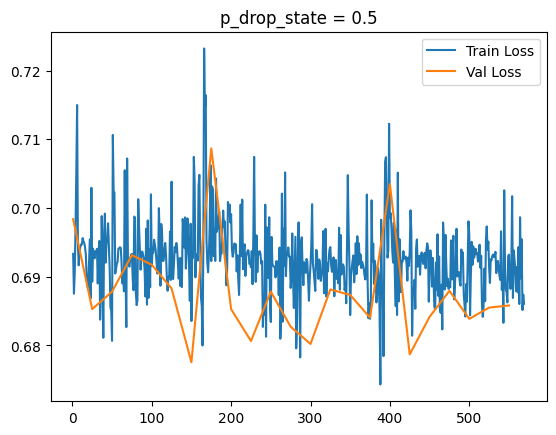

Last train loss: 0.6860455274581909


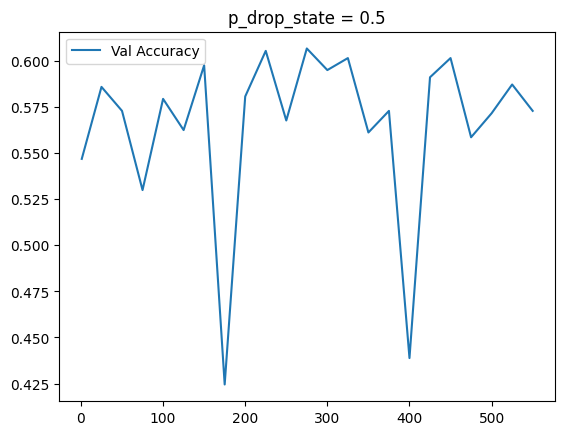

Last val accuracy: 0.5729166865348816


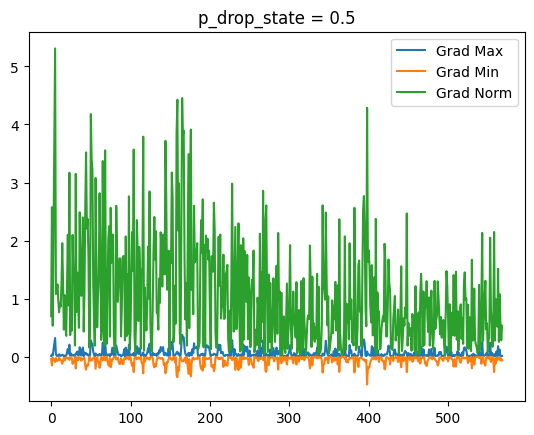

In [77]:
# visualize train and val losses lists on the same plot, scale val by VAL_INTERVAL
import matplotlib.pyplot as plt


train_x_vals = [x[0] for x in train_losses]
train_y_vals = [x[1] for x in train_losses]
val_x_vals = [x[0] for x in val_losses]
val_y_vals = [x[1] for x in val_losses]
plt.plot(train_x_vals, train_y_vals, label='Train Loss')
plt.plot(val_x_vals, val_y_vals, label='Val Loss')

plt.title(f"p_drop_state = {p_drop_state}")
plt.legend()
plt.show()
print(f"Last train loss: {train_y_vals[-1]}")

# plot val_accuracies
plt.plot(val_x_vals, [x[1] for x in val_accuracies], label='Val Accuracy')
plt.title(f"p_drop_state = {p_drop_state}")
plt.legend()
plt.show()
print(f"Last val accuracy: {val_accuracies[-1][1]}")

# also plot grad_max, grad_min, grad_norm
plt.plot([x[1] for x in grad_max], label='Grad Max')
plt.plot([x[1] for x in grad_min], label='Grad Min')
plt.plot([x[1] for x in grad_norm], label='Grad Norm')
plt.title(f"p_drop_state = {p_drop_state}")
plt.legend()
plt.show()

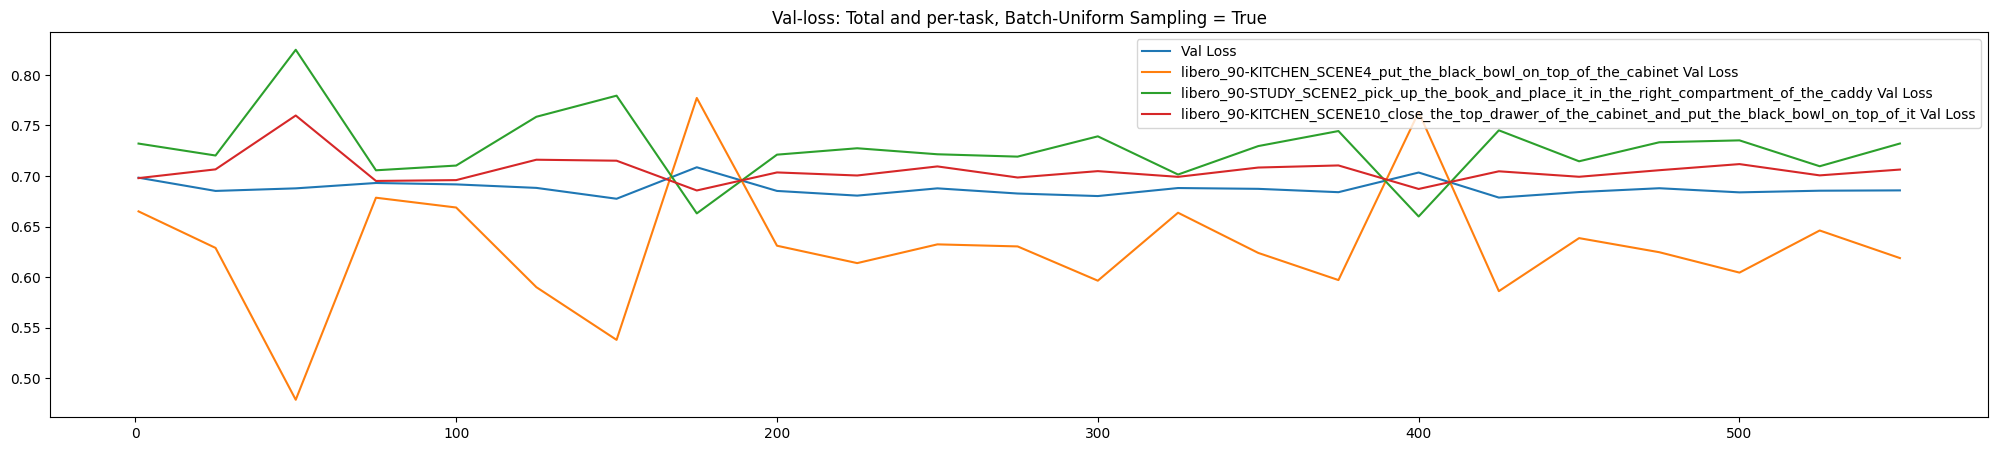

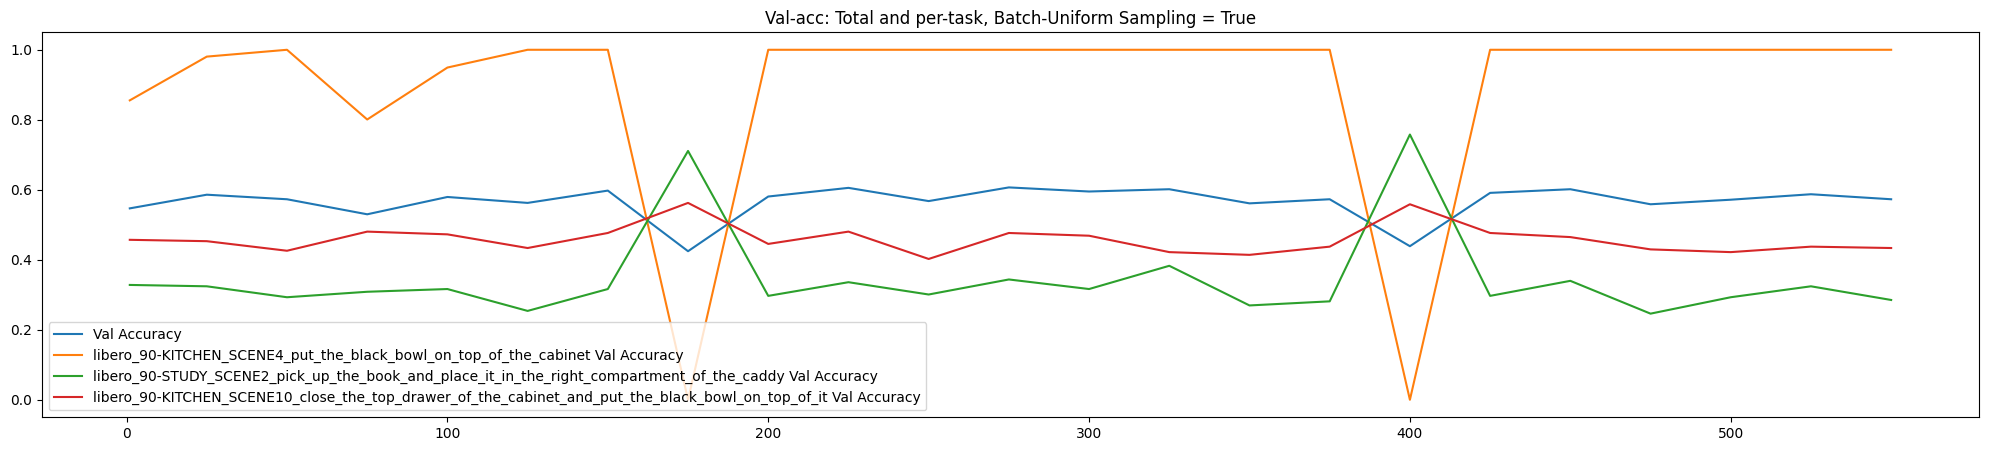

In [78]:
# make 1 plot with val-losses and per-task val-losses
plt.figure(figsize=(25, 5))
plt.plot(val_x_vals, [x[1] for x in val_losses], label='Val Loss')
for eval_name in val_datasets:
    plt.plot(val_x_vals, [x[1] for x in per_task_val_losses[eval_name]], label=f'{eval_name} Val Loss')
# title with batch_sampling
plt.title(f"Val-loss: Total and per-task, Batch-Uniform Sampling = True")
plt.legend(loc='upper right')
plt.show()


# same thing with acc
plt.figure(figsize=(25, 5))
plt.plot(val_x_vals, [x[1] for x in val_accuracies], label='Val Accuracy')
for eval_name in val_datasets:
    plt.plot(val_x_vals, [x[1] for x in per_task_val_accuracies[eval_name]], label=f'{eval_name} Val Accuracy')
plt.title(f"Val-acc: Total and per-task, Batch-Uniform Sampling = True")
plt.legend()
plt.show()

In [ ]:
# def process_task(task_paths, task_str, action_clip_eps=1e-5):
#     observations = []
#     actions = []
#     next_observations = []
#     terminals = []
#     rewards = []
#     masks = []
#     num_timesteps = 0
    
#     for path in tqdm.tqdm(task_paths, total=len(task_paths), desc=f"Processing files for task {task_str}", position=0, leave=True):
#         dataset = pickle.load(open(path, 'rb'))
        
#         # Flatten across all episodes in this file
#         all_obs = [obs for ep in dataset for obs in ep['observations']]
#         all_next_obs = [obs for ep in dataset for obs in ep['next_observations']]
        
#         a = np.concatenate([ep['actions'] for ep in dataset], axis=0)
#         a = np.clip(a, -1 + action_clip_eps, 1 - action_clip_eps)
#         r = np.concatenate([np.array(ep['rewards']) for ep in dataset], axis=0)
#         dones = np.concatenate([np.array(ep['dones']) for ep in dataset], axis=0)
        
#         num_timesteps += a.shape[0]
        
#         observations.append(tree_util.tree_map(lambda x: x.astype(np.float32), batch_dicts(all_obs)))
#         next_observations.append(tree_util.tree_map(lambda x: x.astype(np.float32), batch_dicts(all_next_obs)))
#         actions.append(a.astype(np.float32))
#         rewards.append(r.astype(np.float32))
#         terminals.append(dones.astype(np.float32))
#         masks.append(1.0 - dones.astype(np.float32))
    
#     print(f"Total timesteps: {num_timesteps}")
#     return Dataset.create(
#         observations=stack_dict_list(observations),
#         next_observations=stack_dict_list(next_observations),
#         actions=np.concatenate(actions, axis=0),
#         rewards=np.concatenate(rewards, axis=0),
#         terminals=np.concatenate(terminals, axis=0),
#         masks=np.concatenate(masks, axis=0),
#     )

In [73]:
single_task_dataset = process_task(task_trajs[k], k)

Processing files for task libero_90-KITCHEN_SCENE4_put_the_black_bowl_on_top_of_the_cabinet: 100%|██████████| 6/6 [01:02<00:00, 10.44s/it]


Total timesteps: 12130
